# Machine Learning Foundations - Linear Regression with SGD

**Summary**
This notebook explores the practical implementation of Linear Regression using the **Stochastic Gradient Descent (SGD)** algorithm via `scikit-learn`, focusing on feature scaling and reproducibility.

**Key Takeaways:**

1.  **Data Preparation**: Loading housing data and identifying features (size, bedrooms, floors, age) vs target (price).
2.  **Feature Scaling**: Importance of **Z-score Normalization** (`StandardScaler`) to ensure SGD convergence across features with different scales.
3.  **Model Implementation**: Using `SGDRegressor` for efficient parameter estimation.
4.  **Reproducibility**: Necessity of providing a seed to `random_state` to ensure consistent results across different runs.
---


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

np.set_printoptions(precision=2)

In [23]:
data = pd.read_csv(
    '../../../data/foundations/machine learning foundations/houses_data.csv')

X_train = data.iloc[:, :4].to_numpy()
y_train = data.iloc[:, 4].to_numpy()

data.head()

,size_sqft,bedrooms,floors,age,price_1000s
0,2028,3,2,29,449.40
1,2596,2,2,33,459.22
2,1720,2,1,1,448.85
3,1838,2,1,56,327.82
4,1723,3,1,26,349.09


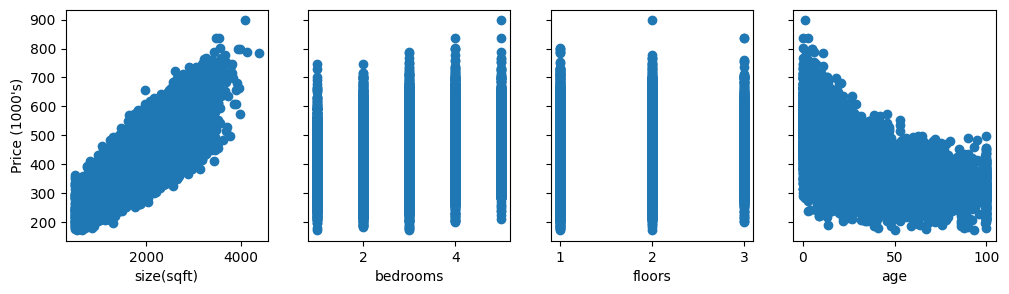

In [25]:
X_features = ['size(sqft)', 'bedrooms', 'floors', 'age']

fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:, i], y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()

In [26]:
#Scaling features with z-score normalization
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)

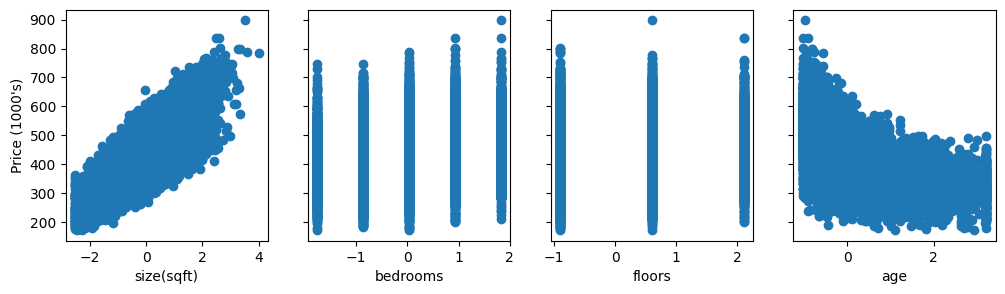

In [27]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_norm[:, i], y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()

In [30]:
sgdr = SGDRegressor(max_iter=1000, random_state=1)
sgdr.fit(X_norm, y_train)

print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

number of iterations completed: 12, number of weight updates: 120001.0


In [31]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_

print(f"Model parameters: intercept = {b_norm}, coefficients = {w_norm}")

Model parameters: intercept = [437.93], coefficients = [ 73.27  18.32   7.65 -54.45]


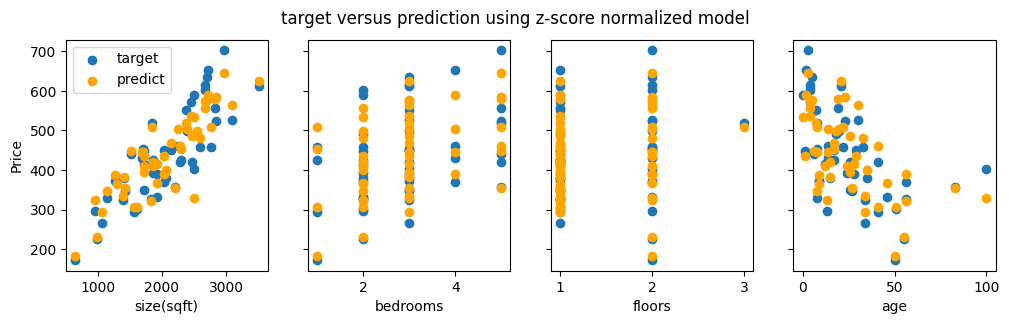

In [35]:
y_pred_sgd = sgdr.predict(X_norm)

m_to_use = 50
# plot predictions and targets vs original features
fig,ax=plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:m_to_use,i],y_train[:m_to_use], label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:m_to_use,i],y_pred_sgd[:m_to_use],color="orange", label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()